In [29]:
# Practical 8: Confidence Interval Estimation and Bootstrapping
# Dataset: supermarket_sales.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# PART A: CONFIDENCE INTERVAL ESTIMATION

In [30]:
# 1. Load the supermarket_sales.csv dataset
df = pd.read_csv("supermarket_sales.csv")

In [31]:
# 2. Display first five records and size of dataset
print("First Five Records:")
print(df.head())
print("\nDataset Size:")
print(df.shape)

First Five Records:
    invoice_id branch       city customer_type gender_customer  \
0  750-67-8428      A     Yangon        Member          Female   
1  226-31-3081      C  Naypyitaw        Normal          Female   
2  631-41-3108      A     Yangon        Normal            Male   
3  123-19-1176      A     Yangon        Member            Male   
4  373-73-7910      A     Yangon        Normal            Male   

             product_line  unit_cost  quantity  5pct_markup   revenue  \
0       Health and beauty      74.69         7      26.1415  548.9715   
1  Electronic accessories      15.28         5       3.8200   80.2200   
2      Home and lifestyle      46.33         7      16.2155  340.5255   
3       Health and beauty      58.22         8      23.2880  489.0480   
4       Sports and travel      86.31         7      30.2085  634.3785   

        date   time payment_method    cogs    gm_pct  gross_income  rating  
0   01/05/19  13:08        Ewallet  522.83  4.761905       26.1415 

In [32]:
# 3. Select the revenue column
revenue = df["revenue"]

In [33]:
# 4. Check and handle missing values
print("\nMissing Values in Revenue:")
print(revenue.isnull().sum())
revenue = revenue.dropna()


Missing Values in Revenue:
0


In [34]:
# 5. Calculate sample size, sample mean and sample standard deviation
n = len(revenue)
sample_mean = revenue.mean()
sample_std = revenue.std()
print("\nSample Size:", n)
print("Sample Mean:", sample_mean)
print("Sample Standard Deviation:", sample_std)


Sample Size: 1000
Sample Mean: 322.966749
Sample Standard Deviation: 245.88533510097187


In [35]:
# 6, 7, 8. Calculate 90%, 95% and 99% Confidence Intervals
confidence_levels = [0.90, 0.95, 0.99]
confidence_results = []
for confidence in confidence_levels:
    standard_error = sample_std / np.sqrt(n)
    margin_error = stats.t.ppf(
        (1 + confidence) / 2,
        df=n - 1
    ) * standard_error
    lower = sample_mean - margin_error
    upper = sample_mean + margin_error
    confidence_results.append([
        confidence * 100,
        lower,
        upper
    ])

In [36]:
# 9. Display confidence intervals in a table
ci_table = pd.DataFrame(
    confidence_results,
    columns=[
        "Confidence Level",
        "Lower Bound",
        "Upper Bound"
    ]
)
print("\nConfidence Intervals:")
print(ci_table)


Confidence Intervals:
   Confidence Level  Lower Bound  Upper Bound
0              90.0   310.165192   335.768306
1              95.0   307.708412   338.225086
2              99.0   302.899854   343.033644


In [37]:
# 10. Compare 90%, 95% and 99% confidence intervals
print("\nComparison of Confidence Intervals:")
for row in confidence_results:
    print(
        f"{row[0]:.0f}% CI: "
        f"{row[1]:.2f} to {row[2]:.2f}"
    )


Comparison of Confidence Intervals:
90% CI: 310.17 to 335.77
95% CI: 307.71 to 338.23
99% CI: 302.90 to 343.03


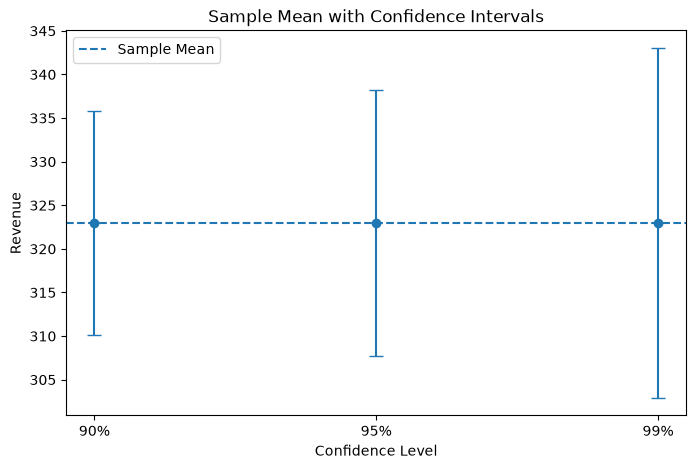

In [38]:
# 11. Visualization of sample mean and confidence intervals
lower_errors = [
    sample_mean - row[1]
    for row in confidence_results
]
upper_errors = [
    row[2] - sample_mean
    for row in confidence_results
]
plt.figure(figsize=(8, 5))
plt.errorbar(
    ["90%", "95%", "99%"],
    [sample_mean] * 3,
    yerr=[lower_errors, upper_errors],
    fmt="o",
    capsize=5
)
plt.axhline(
    sample_mean,
    linestyle="--",
    label="Sample Mean"
)
plt.xlabel("Confidence Level")
plt.ylabel("Revenue")
plt.title("Sample Mean with Confidence Intervals")
plt.legend()
plt.show()

In [39]:
# 12. Interpretation of 95% Confidence Interval
ci_95 = confidence_results[1]
print("\n95% Confidence Interval Interpretation:")
print(
    f"We are 95% confident that the true population "
    f"mean revenue lies between {ci_95[1]:.2f} "
    f"and {ci_95[2]:.2f}."
)


95% Confidence Interval Interpretation:
We are 95% confident that the true population mean revenue lies between 307.71 and 338.23.


In [40]:
# 13. Calculate proportion of customers in each category
customer_type = df["customer_type"].dropna()
customer_counts = customer_type.value_counts()
customer_proportions = customer_type.value_counts(normalize=True)
print("\nCustomer Counts:")
print(customer_counts)
print("\nCustomer Proportions:")
print(customer_proportions)


Customer Counts:
customer_type
Member    501
Normal    499
Name: count, dtype: int64

Customer Proportions:
customer_type
Member    0.501
Normal    0.499
Name: proportion, dtype: float64


In [41]:
# 14. Calculate 95% Confidence Interval for Member customers
member_count = (customer_type == "Member").sum()
total_customers = len(customer_type)
member_proportion = member_count / total_customers
standard_error_proportion = np.sqrt(
    member_proportion *
    (1 - member_proportion) /
    total_customers
)
z_value = stats.norm.ppf(0.975)
margin_error_proportion = (
    z_value * standard_error_proportion
)
proportion_lower = (
    member_proportion -
    margin_error_proportion
)
proportion_upper = (
    member_proportion +
    margin_error_proportion
)
print("\nMember Customer Proportion:")
print(member_proportion)
print("\n95% Confidence Interval for Member Customers:")
print(
    proportion_lower,
    "to",
    proportion_upper
)


Member Customer Proportion:
0.501

95% Confidence Interval for Member Customers:
0.47001031036433716 to 0.5319896896356628


In [42]:
# 15. Interpretation of population proportion
print("\nProportion Interpretation:")
print(
    f"We are 95% confident that the true population "
    f"proportion of Member customers lies between "
    f"{proportion_lower:.4f} and "
    f"{proportion_upper:.4f}."
)


Proportion Interpretation:
We are 95% confident that the true population proportion of Member customers lies between 0.4700 and 0.5320.


# PART B: BOOTSTRAPPING

In [43]:
# 16. Select revenue and calculate original sample median
revenue = df["revenue"].dropna()
original_median = revenue.median()
print("\nOriginal Sample Median:")
print(original_median)


Original Sample Median:
253.848


In [44]:
# 17, 18, 19. Bootstrap sampling 1000 times
bootstrap_medians = []
for i in range(1000):
    bootstrap_sample = revenue.sample(
        n=len(revenue),
        replace=True
    )
    bootstrap_median = bootstrap_sample.median()
    bootstrap_medians.append(bootstrap_median)
bootstrap_medians = np.array(bootstrap_medians)

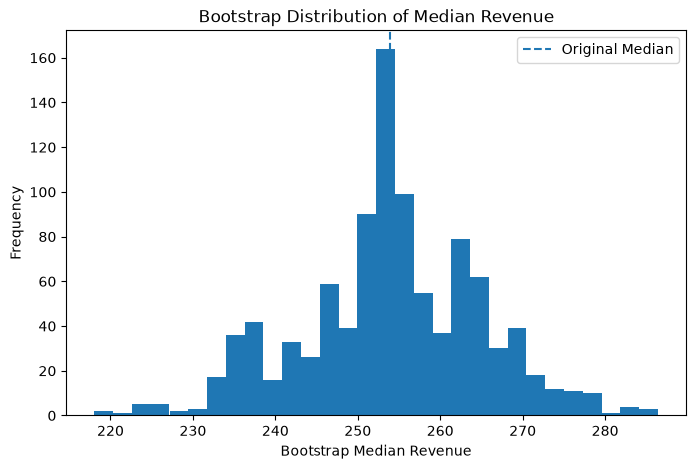

In [45]:
# 20. Histogram of bootstrap median values
plt.figure(figsize=(8, 5))
plt.hist(
    bootstrap_medians,
    bins=30
)
plt.axvline(
    original_median,
    linestyle="--",
    label="Original Median"
)
plt.xlabel("Bootstrap Median Revenue")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Median Revenue")
plt.legend()
plt.show()

In [46]:
# 21. Calculate 2.5th and 97.5th percentiles
lower_percentile = np.percentile(
    bootstrap_medians,
    2.5
)
upper_percentile = np.percentile(
    bootstrap_medians,
    97.5
)
print("\n2.5th Percentile:")
print(lower_percentile)
print("\n97.5th Percentile:")
print(upper_percentile)


2.5th Percentile:
233.163

97.5th Percentile:
276.948


In [47]:
# 22. Calculate 95% Bootstrap Confidence Interval
bootstrap_ci = (
    lower_percentile,
    upper_percentile
)
print("\n95% Bootstrap Confidence Interval:")
print(
    bootstrap_ci[0],
    "to",
    bootstrap_ci[1]
)


95% Bootstrap Confidence Interval:
233.163 to 276.948


In [48]:
# 23. Display original median and bootstrap CI
print("\nOriginal Sample Median:")
print(original_median)
print("\n95% Bootstrap Confidence Interval:")
print(
    f"{bootstrap_ci[0]:.2f} to "
    f"{bootstrap_ci[1]:.2f}"
)


Original Sample Median:
253.848

95% Bootstrap Confidence Interval:
233.16 to 276.95


In [49]:
# 24. Compare original median with confidence interval
print("\nComparison:")
if bootstrap_ci[0] <= original_median <= bootstrap_ci[1]:
    print(
        "The original sample median lies within "
        "the 95% bootstrap confidence interval."
    )
else:
    print(
        "The original sample median lies outside "
        "the 95% bootstrap confidence interval."
    )


Comparison:
The original sample median lies within the 95% bootstrap confidence interval.


In [50]:
# 25. Interpretation
print("\nBootstrap Interpretation:")
print(
    f"We are 95% confident that the population "
    f"median revenue lies approximately between "
    f"{bootstrap_ci[0]:.2f} and "
    f"{bootstrap_ci[1]:.2f}."
)


Bootstrap Interpretation:
We are 95% confident that the population median revenue lies approximately between 233.16 and 276.95.


In [51]:
# 26. Conclusion
print("\nConclusion:")
print(
    "Confidence intervals help businesses estimate "
    "population parameters such as mean revenue and "
    "customer proportions from sample data. "
    "Bootstrapping helps estimate the uncertainty of "
    "statistics such as the median. These techniques "
    "help businesses make better decisions using "
    "sample data."
)


Conclusion:
Confidence intervals help businesses estimate population parameters such as mean revenue and customer proportions from sample data. Bootstrapping helps estimate the uncertainty of statistics such as the median. These techniques help businesses make better decisions using sample data.
